# Experiment 2 — VAE-Based Data Augmentation (Beta-VAE, Time Series)

**QUIDA multimodal fall-detection dataset.** This notebook augments **all four preprocessed datasets**
(`X_imu`, `X_imu_ir`, `X_imu_radar`, `X_imu_ir_radar`) in a **single top-to-bottom run**.

Each dataset is an **independent experiment**: its own scaler, encoder, decoder, Beta-VAE, training
history, synthetic set and evaluation. Nothing is shared across datasets.

**Pipeline:** import → config → load all four → validate → train/val split → build VAE → train →
generate → evaluate (real vs synthetic) → save everything.

> **Model backend.** The Beta-VAE is implemented directly in Keras (same family as TSGM's `BetaVAE`)
> so the notebook is guaranteed to run top-to-bottom, natively produces validation-loss curves, and
> adapts to each dataset's feature dimension. A **TSGM drop-in** is provided at the end — set
> `USE_TSGM = True` in the config and follow the marked cell if your project requires TSGM specifically.


## 1. Import libraries

In [1]:
from __future__ import annotations

import os, json, pickle, random, warnings, time
from pathlib import Path
from dataclasses import dataclass, asdict, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import rbf_kernel
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import pdist

import tensorflow as tf
# Keras 3 is a standalone package (and is what TF >= 2.16 uses internally). Import it
# directly so keras.saving.* is available; fall back to tf.keras on older TF (Keras 2).
try:
    import keras
    from keras import layers
except ImportError:
    from tensorflow import keras
    from tensorflow.keras import layers

# register_keras_serializable / (de)serialize live in different namespaces across
# Keras versions -> resolve them once here so the rest of the notebook is version-agnostic.
_saving = getattr(keras, "saving", None)
def _pick(fn):
    return getattr(_saving, fn, None) or getattr(keras.utils, fn, None)
register_keras_serializable = _pick("register_keras_serializable") or (lambda **k: (lambda c: c))
serialize_keras_object      = _pick("serialize_keras_object")
deserialize_keras_object    = _pick("deserialize_keras_object")

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")

print("TensorFlow:", tf.__version__)
print("Keras     :", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")


TensorFlow: 2.16.1
Keras     : 3.3.3
GPUs: none (CPU)


## 2. Configuration

Everything tunable lives here. The four datasets are declared once; the pipeline iterates over them
automatically. Paths resolve relative to the **current working directory** (local HPC, no Colab / Drive).

In [2]:
@dataclass
class Config:
    # --- data ---
    data_dir: Path = field(default_factory=lambda: Path.cwd())
    output_dir: Path = field(default_factory=lambda: Path.cwd() / "vae_generated")
    dataset_glob: str = "*_raw.npy"       # auto-discovery pattern inside data_dir
    datasets: dict | None = None          # None -> auto-discover; or explicit {name: filename}

    # --- reproducibility ---
    seed: int = 42

    # --- split ---
    val_split: float = 0.2

    # --- model ---
    latent_dim: int = 16
    beta: float = 1.0                 # KL weight (Beta-VAE)
    base_filters: int = 64

    # --- training ---
    epochs: int = 300
    batch_size: int = 64
    learning_rate: float = 1e-3
    early_stopping_patience: int = 25

    # --- generation ---
    synthetic_ratio: float = 1.0      # n_synthetic = ratio * n_real_total

    # --- evaluation ---
    run_tsne: bool = True
    tsne_max_points: int = 500        # per class, keeps t-SNE fast
    eval_subsample: int = 600         # cap for MMD / diversity (speed)

    # --- health thresholds ---
    kl_collapse_thresh: float = 1e-2  # per-dim KL below this ~ posterior collapse
    overfit_ratio: float = 1.5        # val_loss / train_loss above this ~ overfitting

    # --- backend ---
    use_tsgm: bool = False            # True -> use the TSGM drop-in cell instead

CFG = Config()
CFG.output_dir.mkdir(parents=True, exist_ok=True)
print("Data dir  :", CFG.data_dir)
print("Output dir:", CFG.output_dir)
print("Discovery :", CFG.dataset_glob if CFG.datasets is None else "explicit list")


Data dir  : c:\Users\mabideen\Downloads\Data_Augmentation\exp_2
Output dir: c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated
Discovery : *_raw.npy


In [4]:
def set_seeds(seed: int) -> None:
    """Seed python / numpy / tensorflow for reproducible runs."""
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    try:
        keras.utils.set_random_seed(seed)      # TF>=2.7: seeds python+numpy+tf at once
    except Exception:
        tf.random.set_seed(seed)

set_seeds(CFG.seed)


## 3. Automatically discover and load the four datasets

Files matching `dataset_glob` (default `*_raw.npy`) are discovered in `data_dir` and each is loaded as
its **own independent dataset** — never concatenated, stacked, or merged. The folder name is derived from
the filename (`X_imu_ir_radar_raw.npy` -> `X_imu_ir_radar`). Set `CFG.datasets` to an explicit mapping to
override. Missing files are reported clearly.

In [5]:
def _clean_name(filename: str) -> str:
    """X_imu_ir_radar_raw.npy -> X_imu_ir_radar (used as the output-folder name)."""
    stem = Path(filename).stem                       # drop .npy
    return stem[:-4] if stem.endswith("_raw") else stem

def discover_datasets(cfg: Config) -> dict[str, np.ndarray]:
    """Auto-discover the independent datasets in data_dir (or use an explicit list).
    Each file is loaded as its OWN dataset. They are never concatenated or merged."""
    if cfg.datasets:                                 # explicit mapping takes priority
        items = list(cfg.datasets.items())
        missing = [str(cfg.data_dir / f) for _, f in items if not (cfg.data_dir / f).exists()]
        if missing:
            raise FileNotFoundError("Missing dataset file(s):\n  " + "\n  ".join(missing))
    else:                                            # auto-discover by glob pattern
        files = sorted(cfg.data_dir.glob(cfg.dataset_glob),
                       key=lambda q: (q.name.count("_"), q.name))   # shorter combos first
        if not files:
            raise FileNotFoundError(
                f"No files matching {cfg.dataset_glob!r} in {cfg.data_dir}")
        items = [(_clean_name(q.name), q.name) for q in files]

    data = {}
    for name, fname in items:
        arr = np.load(cfg.data_dir / fname, allow_pickle=False).astype(np.float32)
        data[name] = arr
        print(f"  discovered {name:16s} <- {fname:26s} shape={arr.shape}")
    print(f"\n  {len(data)} independent dataset(s) - each trained separately, never merged.")
    return data

RAW = discover_datasets(CFG)


  discovered X_imu            <- X_imu_raw.npy              shape=(99, 32, 3)
  discovered X_imu_ir         <- X_imu_ir_raw.npy           shape=(99, 32, 771)
  discovered X_imu_radar      <- X_imu_radar_raw.npy        shape=(99, 32, 1137)
  discovered X_imu_ir_radar   <- X_imu_ir_radar_raw.npy     shape=(99, 32, 1905)

  4 independent dataset(s) - each trained separately, never merged.


## 4. Data validation

Confirms every dataset is 3-D `(samples, seq_len, features)`, finite, and non-empty. NaN/Inf values
(if any) are reported and mean-imputed per feature so training does not silently diverge.

In [6]:
def load_metadata(cfg: Config, name: str):
    """Load companion metadata if present (<name>_meta.json / .json / _meta.csv); else None."""
    for cand in (f"{name}_meta.json", f"{name}.json", f"{name}_meta.csv"):
        q = cfg.data_dir / cand
        if q.exists():
            return json.loads(q.read_text()) if q.suffix == ".json" else pd.read_csv(q).to_dict("list")
    return None

def validate_dataset(name: str, X: np.ndarray, cfg: Config) -> np.ndarray:
    assert X.ndim == 3, f"{name}: expected 3-D (N, T, F), got {X.shape}"
    N, T, F = X.shape
    assert N > 0 and T > 0 and F > 0, f"{name}: empty axis in {X.shape}"
    n_nan, n_inf = int(np.isnan(X).sum()), int(np.isinf(X).sum())
    if n_nan or n_inf:
        print(f"  ! {name}: {n_nan} NaN / {n_inf} Inf -> imputing per-feature mean")
        X = np.where(np.isfinite(X), X, np.nan)
        feat_mean = np.nan_to_num(np.nanmean(X.reshape(-1, F), axis=0))
        inds = np.where(~np.isfinite(X))
        X[inds] = np.take(feat_mean, inds[2])
    meta = load_metadata(cfg, name)
    meta_msg = f"metadata={list(meta)}" if meta else "metadata=none"
    print(f"  {name:16s} N={N:<5d} T={T:<4d} F={F:<3d} "
          f"min={X.min():+.3f} max={X.max():+.3f} mean={X.mean():+.3f} | {meta_msg}")
    if F > N or N < 200:
        print(f"    [readiness] {name}: {N} samples for {F} features -> the VAE will likely "
              f"overfit; treat synthetic data as approximate (more data / smaller latent_dim help).")
    return X.astype(np.float32)

RAW = {name: validate_dataset(name, X, CFG) for name, X in RAW.items()}


  X_imu            N=99    T=32   F=3   min=-73.381 max=+72.094 mean=+1.734 | metadata=none
    [readiness] X_imu: 99 samples for 3 features -> the VAE will likely overfit; treat synthetic data as approximate (more data / smaller latent_dim help).
  X_imu_ir         N=99    T=32   F=771 min=-73.381 max=+72.094 mean=+23.992 | metadata=none
    [readiness] X_imu_ir: 99 samples for 771 features -> the VAE will likely overfit; treat synthetic data as approximate (more data / smaller latent_dim help).
  X_imu_radar      N=99    T=32   F=1137 min=-73.381 max=+1522.992 mean=+14.305 | metadata=none
    [readiness] X_imu_radar: 99 samples for 1137 features -> the VAE will likely overfit; treat synthetic data as approximate (more data / smaller latent_dim help).
  X_imu_ir_radar   N=99    T=32   F=1905 min=-73.381 max=+1522.992 mean=+18.245 | metadata=none
    [readiness] X_imu_ir_radar: 99 samples for 1905 features -> the VAE will likely overfit; treat synthetic data as approximate (more data /

## 5. Train / Validation split (+ per-dataset scaling)

Each dataset gets **its own** split and **its own** `MinMaxScaler`. The scaler is fit on **training data
only** (no leakage) and applied to both splits. Because `MinMaxScaler` is 2-D, we reshape
`(N, T, F) -> (N*T, F)` and back.

In [7]:
def split_and_scale(X: np.ndarray, cfg: Config):
    X_tr, X_val = train_test_split(X, test_size=cfg.val_split,
                                   random_state=cfg.seed, shuffle=True)
    N, T, F = X_tr.shape
    scaler = MinMaxScaler()
    scaler.fit(X_tr.reshape(-1, F))                      # fit on TRAIN only

    def apply(a):
        n = len(a)
        return scaler.transform(a.reshape(-1, F)).reshape(n, T, F).astype(np.float32)

    return apply(X_tr), apply(X_val), scaler, (T, F)

def inverse_scale(scaler, X_scaled):
    n, T, F = X_scaled.shape
    return scaler.inverse_transform(X_scaled.reshape(-1, F)).reshape(n, T, F)


## 6. Build the Beta-VAE

A convolutional encoder/decoder pair wrapped in a `BetaVAE` `keras.Model` with **`train_step` and
`test_step`** — the `test_step` is what yields native **validation** reconstruction/KL/total-loss curves.

The decoder reshapes a dense projection straight to `(T, C)`, so output length always equals the input
length for **any** `T`/`F` — this is why the same builder works for all four differently-shaped datasets.
Decoder output is `sigmoid` because data is scaled to `[0, 1]`.

In [8]:
@register_keras_serializable()
class Sampling(layers.Layer):
    """Reparameterization: z = mean + exp(0.5*log_var) * eps."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps


def build_encoder(T, F, latent_dim, base):
    x_in = keras.Input(shape=(T, F))
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x_in)
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x)
    x = layers.Conv1D(base // 2, 3, padding="same", activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(base, activation="relu")(x)
    z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(x_in, [z_mean, z_log_var, z], name="encoder")


def build_decoder(T, F, latent_dim, base):
    z_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(base, activation="relu")(z_in)
    x = layers.Dense(T * (base // 2), activation="relu")(x)
    x = layers.Reshape((T, base // 2))(x)                # -> exact length T for any T
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x)
    x = layers.Conv1D(base, 3, padding="same", activation="relu")(x)
    out = layers.Conv1D(F, 3, padding="same", activation="sigmoid")(x)
    return keras.Model(z_in, out, name="decoder")


In [9]:
@register_keras_serializable()
class BetaVAE(keras.Model):
    """Beta-VAE for time series (canonical Keras 3 subclassed-VAE pattern:
    custom train_step + metrics property). Validation losses are logged by
    ValLossCallback, so we deliberately do NOT define test_step / pass
    validation_data -- that combination triggers a Keras 3 tracking bug
    ('TrackedList' object is not callable)."""
    def __init__(self, encoder, decoder, beta=1.0, **kw):
        super().__init__(**kw)
        self.encoder, self.decoder, self.beta = encoder, decoder, float(beta)
        self.total_tracker = keras.metrics.Mean(name="total_loss")
        self.rec_tracker   = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_tracker    = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_tracker, self.rec_tracker, self.kl_tracker]

    def compute_losses(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        recon = self.decoder(z)
        rec = tf.reduce_mean(tf.reduce_sum(tf.square(x - recon), axis=[1, 2]))
        kl  = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1))
        return rec, kl, rec + self.beta * kl

    def train_step(self, data):
        x = data[0] if isinstance(data, (tuple, list)) else data
        with tf.GradientTape() as tape:
            rec, kl, total = self.compute_losses(x)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_tracker.update_state(total)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        return {"loss": self.total_tracker.result(),
                "reconstruction_loss": self.rec_tracker.result(),
                "kl_loss": self.kl_tracker.result()}

    def call(self, x, training=None):
        _, _, z = self.encoder(x)
        return self.decoder(z)

    def get_config(self):
        return {"encoder": serialize_keras_object(self.encoder),
                "decoder": serialize_keras_object(self.decoder),
                "beta": self.beta}

    @classmethod
    def from_config(cls, config):
        return cls(deserialize_keras_object(config["encoder"]),
                   deserialize_keras_object(config["decoder"]),
                   beta=config["beta"])


def build_vae(T, F, cfg: Config) -> BetaVAE:
    enc = build_encoder(T, F, cfg.latent_dim, cfg.base_filters)
    dec = build_decoder(T, F, cfg.latent_dim, cfg.base_filters)
    vae = BetaVAE(enc, dec, beta=cfg.beta)
    vae.compile(optimizer=keras.optimizers.Adam(cfg.learning_rate))
    return vae


## 7. Train the VAE

Callbacks: **EarlyStopping** (restores best weights), **ModelCheckpoint** (best weights backup on disk),
and a custom **`VAEHealthMonitor`** that watches for **posterior collapse** (KL → 0) live during training.

In [10]:
class ValLossCallback(keras.callbacks.Callback):
    """Compute validation reconstruction / KL / total loss each epoch (eager) and inject
    them into `logs` so EarlyStopping / ModelCheckpoint / ReduceLROnPlateau / History all
    see val_loss. Runs FIRST in the callback list. Replaces validation_data + test_step
    (which trips a Keras 3 tracking bug)."""
    def __init__(self, X_val, beta, batch_size=128):
        super().__init__()
        self.X_val = X_val.astype("float32"); self.beta = float(beta); self.bs = int(batch_size)

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            return
        recs, kls, ns = [], [], []
        for i in range(0, len(self.X_val), self.bs):
            xb = self.X_val[i:i + self.bs]
            z_mean, z_log_var, z = self.model.encoder(xb, training=False)
            recon = self.model.decoder(z, training=False)
            rec = float(tf.reduce_mean(tf.reduce_sum(tf.square(xb - recon), axis=[1, 2])))
            kl  = float(-0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)))
            recs.append(rec); kls.append(kl); ns.append(len(xb))
        w = np.asarray(ns, dtype="float64"); w /= w.sum()
        vrec = float(np.dot(w, recs)); vkl = float(np.dot(w, kls))
        logs["val_reconstruction_loss"] = vrec
        logs["val_kl_loss"] = vkl
        logs["val_loss"] = vrec + self.beta * vkl


class VAEHealthMonitor(keras.callbacks.Callback):
    """Warns during training if the KL term collapses toward zero (posterior collapse)."""
    def __init__(self, latent_dim, thresh):
        super().__init__(); self.per_dim_thresh = thresh * latent_dim; self.hits = 0
    def on_epoch_end(self, epoch, logs=None):
        kl = (logs or {}).get("val_kl_loss", (logs or {}).get("kl_loss"))
        if kl is not None and kl < self.per_dim_thresh:
            self.hits += 1
            if self.hits == 3:
                print(f"    [warn] KL={kl:.4f} very low for 3 epochs -> possible posterior "
                      f"collapse (consider lowering beta or KL-annealing).")
        else:
            self.hits = 0


def train_vae(vae, X_tr, X_val, cfg: Config, ckpt_path: Path):
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    cbs = [
        ValLossCallback(X_val, cfg.beta, cfg.batch_size),          # must run first
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=cfg.early_stopping_patience,
                                      restore_best_weights=True, verbose=0),
        keras.callbacks.ModelCheckpoint(str(ckpt_path), monitor="val_loss",
                                        save_best_only=True, save_weights_only=True, verbose=0),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10,
                                          min_lr=1e-5, verbose=0),
        VAEHealthMonitor(cfg.latent_dim, cfg.kl_collapse_thresh),
    ]
    t0 = time.time()
    hist = vae.fit(X_tr, epochs=cfg.epochs, batch_size=cfg.batch_size,
                   shuffle=True, verbose=0, callbacks=cbs)
    print(f"    trained {len(hist.history['loss'])} epochs in {time.time()-t0:.1f}s "
          f"| best val_loss={min(hist.history['val_loss']):.4f}")
    return hist


## 8. Generate synthetic samples

Sample `z ~ N(0, I)`, decode, then **inverse-transform** back to the original feature scale so the
synthetic `.npy` is directly comparable to the raw data.

In [11]:
def generate_samples(vae, scaler, n, cfg: Config):
    z = np.random.normal(size=(n, cfg.latent_dim)).astype(np.float32)
    scaled = vae.decoder.predict(z, batch_size=256, verbose=0)   # in [0, 1]
    return inverse_scale(scaler, scaled).astype(np.float32), scaled


## 9. Evaluate generated samples (real vs synthetic)

Metrics: reconstruction / KL / total loss (train & val), **MMD** (multi-bandwidth RBF), **Wasserstein**,
per-feature **mean/std** error, **correlation preservation**, and a **diversity** check (mean pairwise
distance — guards against mode collapse). Visuals: loss curves, PCA, t-SNE, per-feature distributions.

In [12]:
def _flat(a, cap, rng):
    a = a.reshape(len(a), -1)
    if len(a) > cap:
        a = a[rng.choice(len(a), cap, replace=False)]
    return a

def mmd_rbf(real, synth, cap, rng):
    X, Y = _flat(real, cap, rng), _flat(synth, cap, rng)
    med = np.median(pdist(X[:200])) if len(X) > 1 else 1.0
    med = med if med > 0 else 1.0
    return float(np.mean([
        rbf_kernel(X, X, g/med**2).mean() + rbf_kernel(Y, Y, g/med**2).mean()
        - 2*rbf_kernel(X, Y, g/med**2).mean() for g in (0.5, 1.0, 2.0)]))

def wasserstein_feat(real, synth):
    F = real.shape[-1]
    return float(np.mean([wasserstein_distance(real[..., f].ravel(), synth[..., f].ravel())
                          for f in range(F)]))

def moment_errors(real, synth):
    return (float(np.mean(np.abs(real.mean((0,1)) - synth.mean((0,1))))),
            float(np.mean(np.abs(real.std((0,1))  - synth.std((0,1))))))

def corr_preservation(real, synth):
    F = real.shape[-1]
    Cr = np.corrcoef(real.reshape(-1, F).T); Cs = np.corrcoef(synth.reshape(-1, F).T)
    return float(np.linalg.norm(np.nan_to_num(Cr) - np.nan_to_num(Cs)))

def diversity(a, cap, rng):
    a = _flat(a, cap, rng)
    return float(pdist(a).mean()) if len(a) > 1 else 0.0

def evaluate(real, synth, hist, cfg: Config):
    rng = np.random.default_rng(cfg.seed)
    md, sd = moment_errors(real, synth)
    div_r, div_s = diversity(real, cfg.eval_subsample, rng), diversity(synth, cfg.eval_subsample, rng)
    return {
        "final_total_loss":  float(hist.history["loss"][-1]),
        "final_recon_loss":  float(hist.history["reconstruction_loss"][-1]),
        "final_kl_loss":     float(hist.history["kl_loss"][-1]),
        "final_val_loss":    float(hist.history["val_loss"][-1]),
        "best_val_loss":     float(min(hist.history["val_loss"])),
        "mmd":               mmd_rbf(real, synth, cfg.eval_subsample, rng),
        "wasserstein":       wasserstein_feat(real, synth),
        "mean_abs_err":      md,
        "std_abs_err":       sd,
        "corr_frobenius":    corr_preservation(real, synth),
        "diversity_real":    div_r,
        "diversity_synth":   div_s,
        "diversity_ratio":   float(div_s / div_r) if div_r else 0.0,
    }


In [13]:
def make_plots(name, real, synth, hist, out_dir: Path, cfg: Config):
    rng = np.random.default_rng(cfg.seed)
    # 1) loss curves
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for i, k in enumerate(["loss", "reconstruction_loss", "kl_loss"]):
        ax[i].plot(hist.history[k], label="train")
        ax[i].plot(hist.history["val_" + k], label="val")
        ax[i].set_title(k); ax[i].set_xlabel("epoch"); ax[i].legend(); ax[i].grid(alpha=.3)
    fig.suptitle(f"{name} — training curves"); fig.tight_layout()
    fig.savefig(out_dir / "loss_curves.png", dpi=110); plt.show(); plt.close(fig)

    # 2) PCA + t-SNE
    r = _flat(real, cfg.tsne_max_points, rng); s = _flat(synth, cfg.tsne_max_points, rng)
    X = np.vstack([r, s]); y = np.r_[np.zeros(len(r)), np.ones(len(s))]
    fig, ax = plt.subplots(1, 2 if cfg.run_tsne else 1, figsize=(12, 5), squeeze=False)
    p = PCA(2, random_state=cfg.seed).fit_transform(X)
    for lbl, m in [(0, "real"), (1, "synth")]:
        ax[0][0].scatter(*p[y==lbl].T, s=8, alpha=.5, label=m)
    ax[0][0].set_title(f"{name} — PCA"); ax[0][0].legend(); ax[0][0].grid(alpha=.3)
    if cfg.run_tsne:
        try:
            perp = max(5, min(30, len(X)//4))
            t = TSNE(2, perplexity=perp, init="pca", random_state=cfg.seed).fit_transform(X)
            for lbl, m in [(0, "real"), (1, "synth")]:
                ax[0][1].scatter(*t[y==lbl].T, s=8, alpha=.5, label=m)
            ax[0][1].set_title(f"{name} — t-SNE"); ax[0][1].legend(); ax[0][1].grid(alpha=.3)
        except Exception as e:
            ax[0][1].text(.5, .5, f"t-SNE skipped\n{e}", ha="center")
    fig.tight_layout(); fig.savefig(out_dir / "pca_tsne.png", dpi=110); plt.show(); plt.close(fig)

    # 3) per-feature distributions (up to 6)
    F = real.shape[-1]; k = min(F, 6)
    fig, ax = plt.subplots(1, k, figsize=(3.2*k, 3.2), squeeze=False)
    for f in range(k):
        ax[0][f].hist(real[..., f].ravel(), bins=40, alpha=.5, density=True, label="real")
        ax[0][f].hist(synth[..., f].ravel(), bins=40, alpha=.5, density=True, label="synth")
        ax[0][f].set_title(f"feat {f}"); ax[0][f].legend(fontsize=7)
    fig.suptitle(f"{name} — feature distributions"); fig.tight_layout()
    fig.savefig(out_dir / "distributions.png", dpi=110); plt.show(); plt.close(fig)


### Automated health checks

After training, each model is flagged for **posterior collapse**, **KL≈0**, **decoder saturation**
(near-constant output), and **overfitting** (val ≫ train). Warnings are collected per dataset.

In [14]:
def health_report(name, synth_scaled, metrics, cfg: Config):
    warns = []
    if metrics["final_kl_loss"] < cfg.kl_collapse_thresh * cfg.latent_dim:
        warns.append("posterior collapse (KL ~ 0)")
    if metrics["best_val_loss"] and metrics["final_val_loss"] > cfg.overfit_ratio * metrics["final_total_loss"]:
        warns.append("possible overfitting (val >> train)")
    if synth_scaled.std() < 1e-3:
        warns.append("decoder saturation (near-constant output)")
    if metrics["diversity_ratio"] < 0.5:
        warns.append("low diversity (possible mode collapse)")
    if warns:
        for w in warns: print(f"    [warn] {name}: {w}")
    else:
        print(f"    [ok] {name}: no health issues flagged")
    return warns


## 10. Save generated datasets and evaluation outputs

Per dataset: `synthetic.npy`, `metadata.csv`, `scaler.pkl`, `model.keras` (+ `encoder.keras` /
`decoder.keras` for reliable reuse), `metrics.json`, and the figures.

In [15]:
def save_outputs(name, out_dir, synthetic, scaler, vae, metrics, meta, warns):
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / "synthetic.npy", synthetic)
    with open(out_dir / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    # functional sub-models always serialize cleanly; full model best-effort
    vae.decoder.save(out_dir / "decoder.keras")
    vae.encoder.save(out_dir / "encoder.keras")
    try:
        vae.save(out_dir / "model.keras")
    except Exception as e:
        vae.save_weights(out_dir / "model.weights.h5")
        print(f"    [note] full model save fell back to weights ({e})")
    pd.DataFrame([meta]).to_csv(out_dir / "metadata.csv", index=False)
    with open(out_dir / "metrics.json", "w") as f:
        json.dump({**metrics, "warnings": warns}, f, indent=2)


## Run all four datasets (single execution)

Each dataset is a self-contained experiment. A failure in one is caught and reported so the others still
complete. A cross-dataset summary is printed and saved at the end.


EXPERIMENT 1/4: X_imu  (own scaler / VAE / optimizer)
    split: train=79 val=20 | T=32 F=3

    [warn] KL=0.0024 very low for 3 epochs -> possible posterior collapse (consider lowering beta or KL-annealing).
    trained 56 epochs in 5.3s | best val_loss=0.3211
    generated 99 synthetic samples, shape=(99, 32, 3)
    [warn] X_imu: posterior collapse (KL ~ 0)
    [warn] X_imu: low diversity (possible mode collapse)


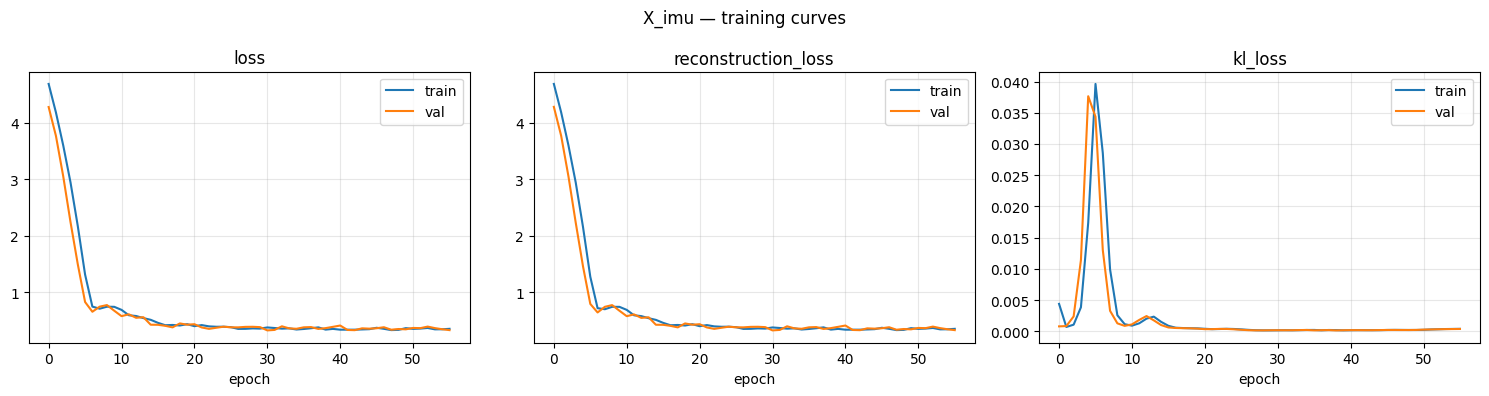

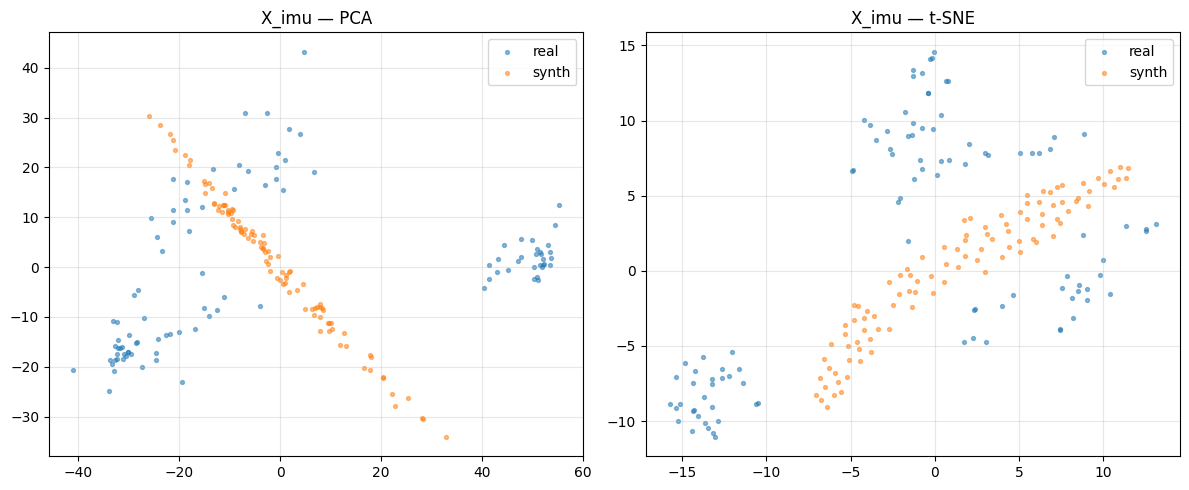

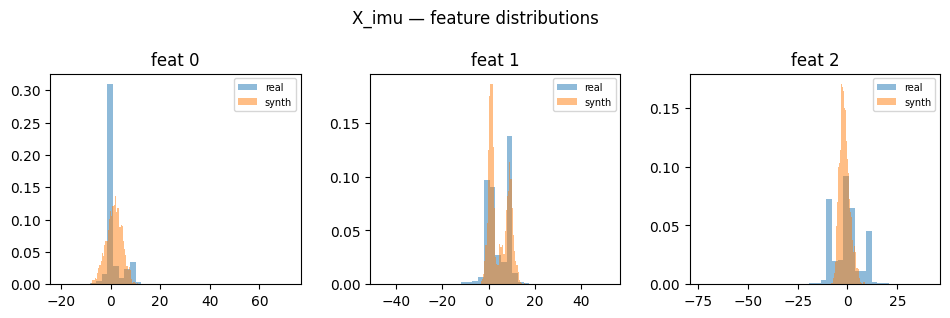

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu

EXPERIMENT 2/4: X_imu_ir  (own scaler / VAE / optimizer)
    split: train=79 val=20 | T=32 F=771
    trained 300 epochs in 23.0s | best val_loss=341.2202
    generated 99 synthetic samples, shape=(99, 32, 771)
    [warn] X_imu_ir: low diversity (possible mode collapse)


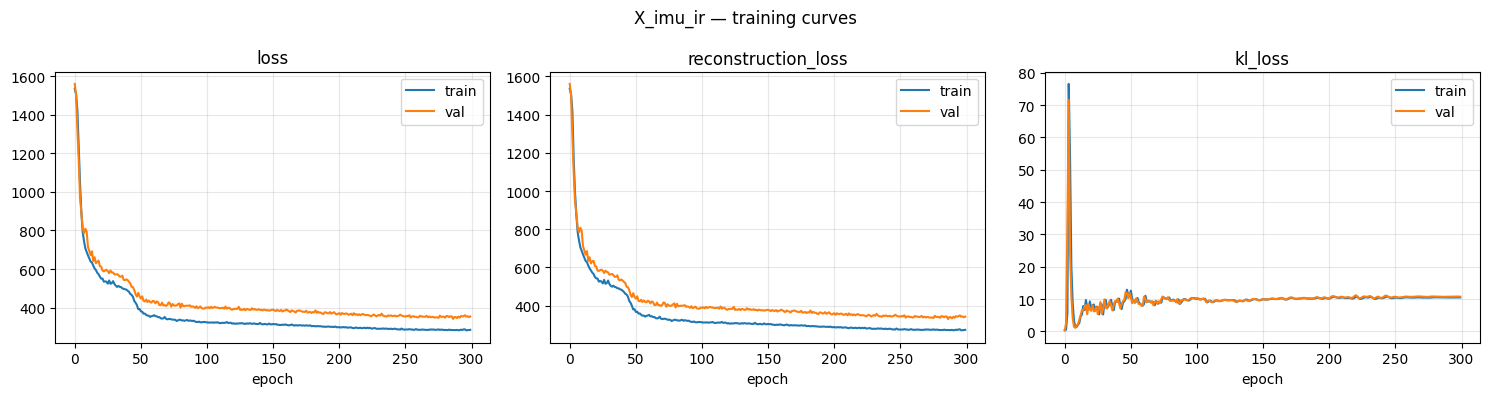

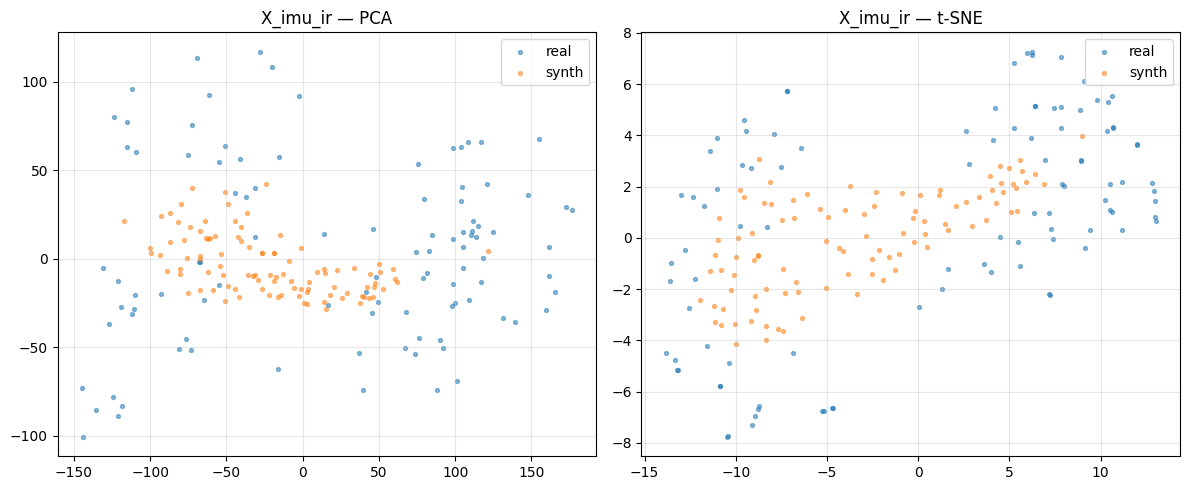

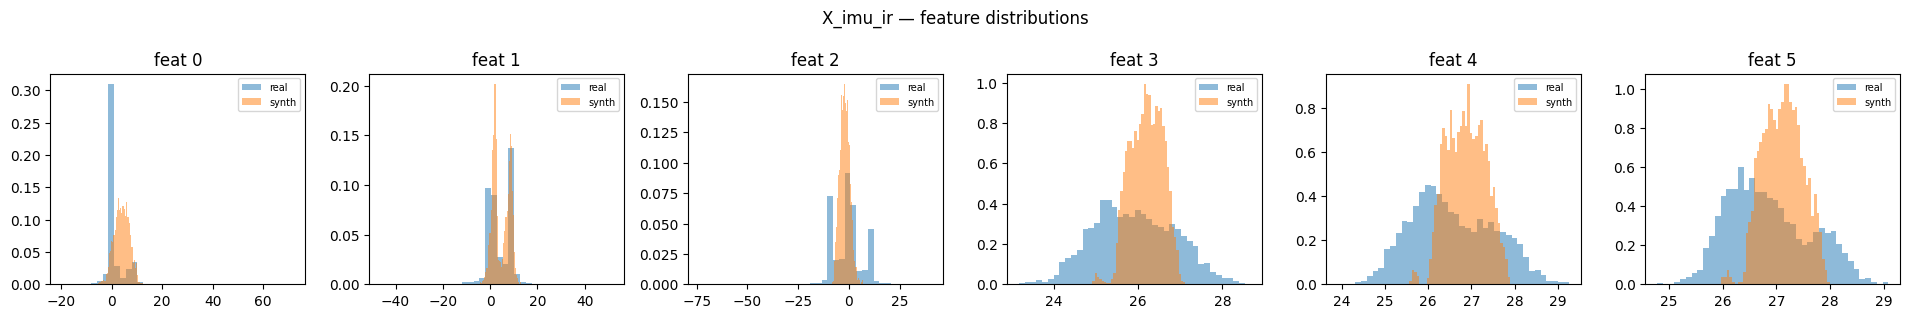

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu_ir

EXPERIMENT 3/4: X_imu_radar  (own scaler / VAE / optimizer)
    split: train=79 val=20 | T=32 F=1137
    trained 230 epochs in 20.9s | best val_loss=500.8612
    generated 99 synthetic samples, shape=(99, 32, 1137)


c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    [warn] X_imu_radar: low diversity (possible mode collapse)


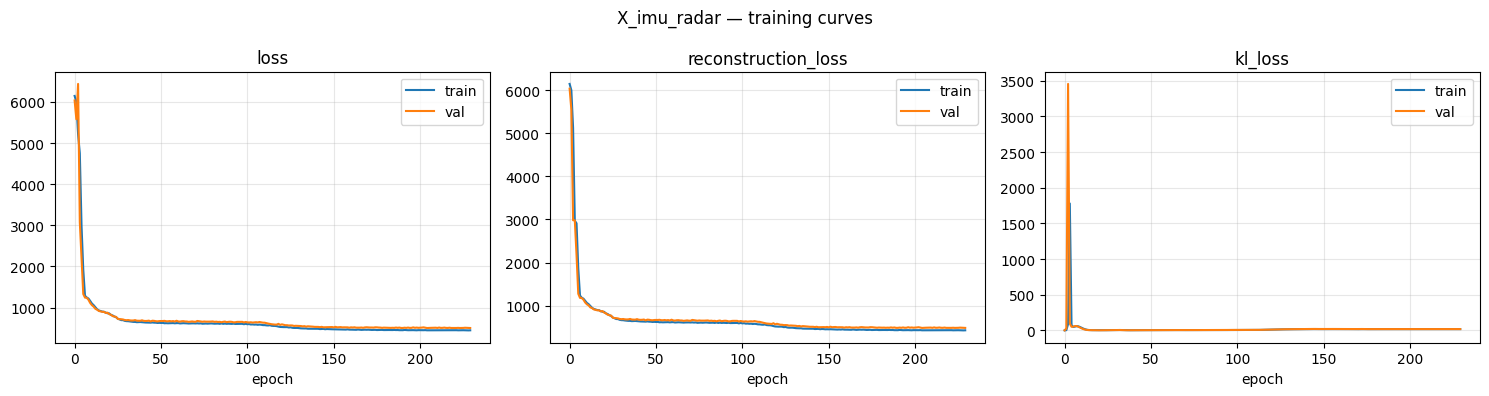

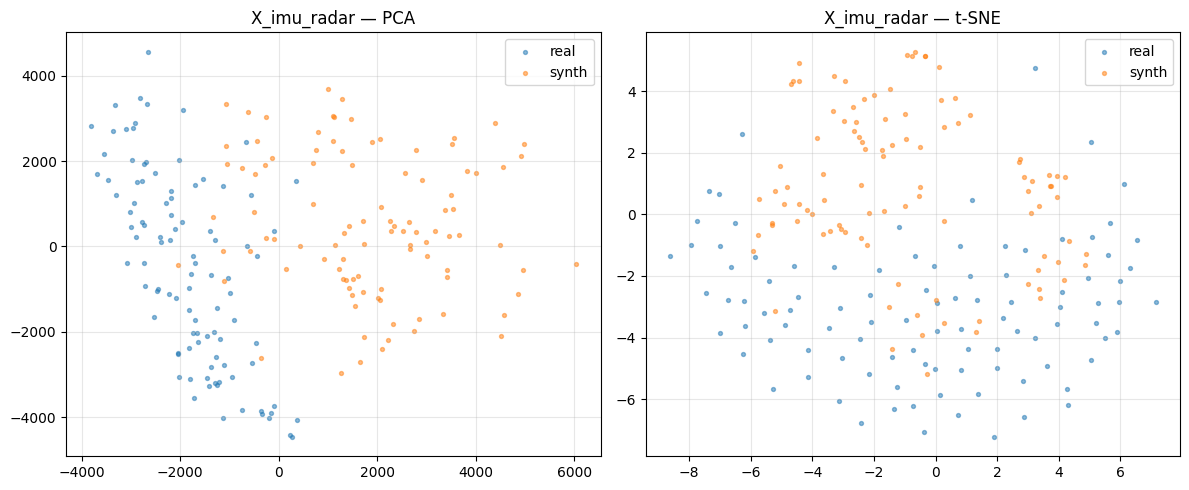

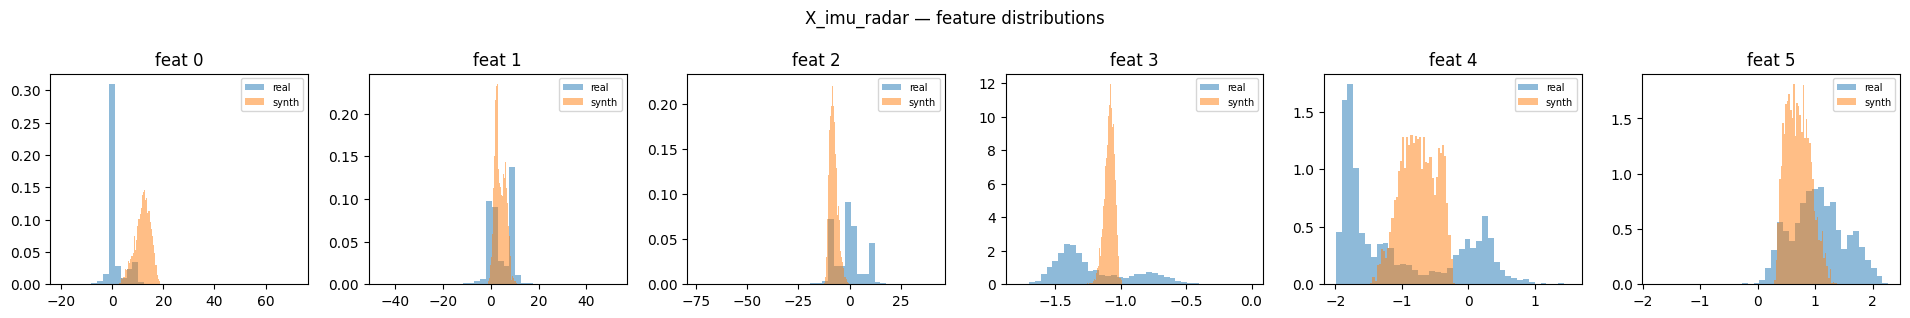

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu_radar

EXPERIMENT 4/4: X_imu_ir_radar  (own scaler / VAE / optimizer)
    split: train=79 val=20 | T=32 F=1905
    trained 226 epochs in 26.2s | best val_loss=801.2709
    generated 99 synthetic samples, shape=(99, 32, 1905)


c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\mabideen\AppData\Local\miniforge3\envs\exp2_env\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


    [ok] X_imu_ir_radar: no health issues flagged


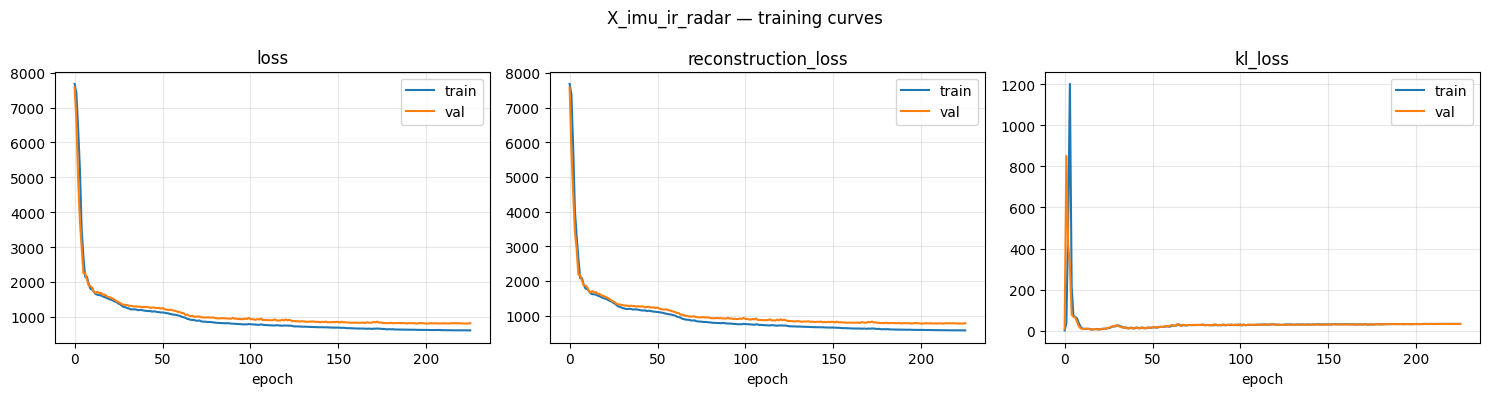

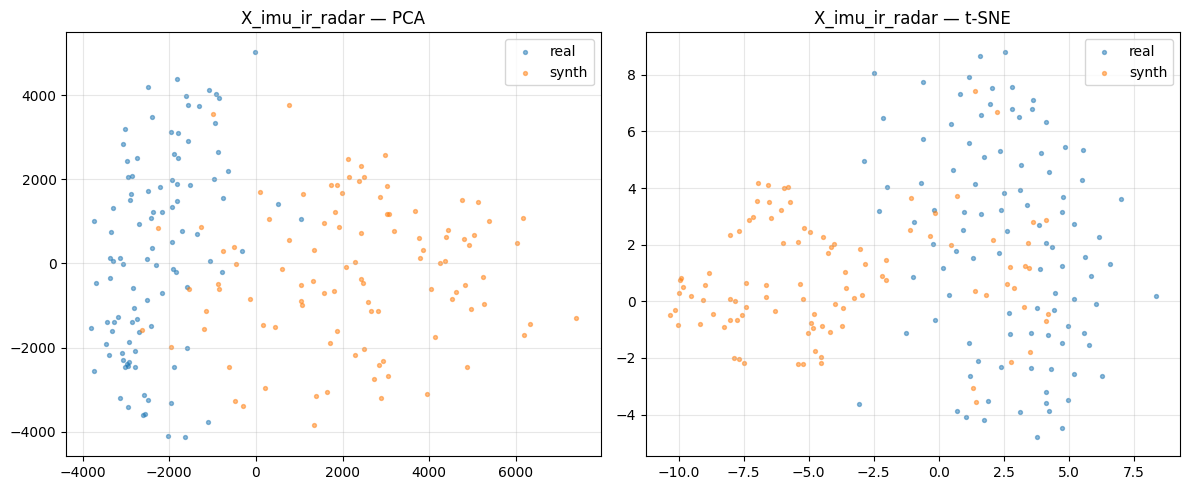

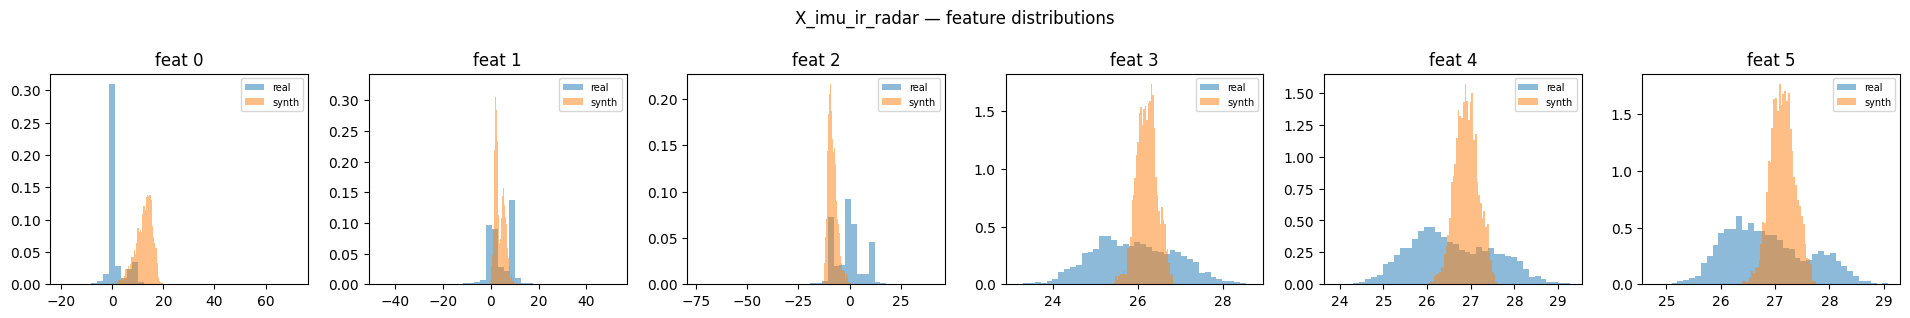

    saved -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu_ir_radar

CROSS-DATASET SUMMARY (independent experiments)


,n_real,n_synth,epochs_run,best_val_loss,mmd,wasserstein,mean_abs_err,std_abs_err,corr_frobenius,diversity_ratio
dataset,,,,,,,,,,
X_imu,99,99,56,0.32108,0.16852,2.22588,0.28269,2.51852,1.14842,0.36906
X_imu_ir,99,99,300,341.22023,0.21203,0.48931,0.25986,0.46276,219.83250,0.34852
X_imu_radar,99,99,230,500.86119,0.30067,10.34150,6.02977,5.06674,670.27100,0.44622
X_imu_ir_radar,99,99,226,801.27086,0.30293,7.25975,5.06215,3.01923,690.96401,0.59356


In [16]:
SEP = "=" * 50

def run_experiment(idx, total, name, X, cfg: Config):
    print(f"\n{SEP}\nEXPERIMENT {idx}/{total}: {name}  (own scaler / VAE / optimizer)\n{SEP}")
    assert isinstance(X, np.ndarray) and X.ndim == 3, "each experiment trains on ONE dataset only"
    set_seeds(cfg.seed)                       # reset RNG so every experiment starts identically
    out_dir = cfg.output_dir / name

    X_tr, X_val, scaler, (T, F) = split_and_scale(X, cfg)
    print(f"    split: train={len(X_tr)} val={len(X_val)} | T={T} F={F}")

    vae = build_vae(T, F, cfg)
    hist = train_vae(vae, X_tr, X_val, cfg, out_dir / "best.weights.h5")

    n_synth = int(round(cfg.synthetic_ratio * len(X)))
    synthetic, synth_scaled = generate_samples(vae, scaler, n_synth, cfg)
    print(f"    generated {len(synthetic)} synthetic samples, shape={synthetic.shape}")

    metrics = evaluate(X, synthetic, hist, cfg)
    warns = health_report(name, synth_scaled, metrics, cfg)
    make_plots(name, X, synthetic, hist, out_dir, cfg)

    meta = {"dataset": name, "n_real": len(X), "n_synth": len(synthetic),
            "seq_len": T, "n_features": F, "latent_dim": cfg.latent_dim, "beta": cfg.beta,
            "epochs_run": len(hist.history["loss"]), **metrics}
    save_outputs(name, out_dir, synthetic, scaler, vae, metrics, meta, warns)
    print(f"    saved -> {out_dir}")
    return meta


def run_all(cfg: Config):
    rows, failures = [], {}
    items = list(RAW.items())
    for i, (name, X) in enumerate(items, 1):
        try:
            rows.append(run_experiment(i, len(items), name, X, cfg))
        except Exception as e:                # one dataset failing must not kill the rest
            failures[name] = repr(e)
            print(f"    [ERROR] {name} failed: {e!r}")
    summary = pd.DataFrame(rows).set_index("dataset") if rows else pd.DataFrame()
    if not summary.empty:
        summary.to_csv(cfg.output_dir / "summary.csv")
    if failures:
        print("\nFailures:", failures)
    return summary

if not CFG.use_tsgm:
    SUMMARY = run_all(CFG)
    print("\n" + "=" * 50 + "\nCROSS-DATASET SUMMARY (independent experiments)\n" + "=" * 50)
    cols = ["n_real","n_synth","epochs_run","best_val_loss","mmd","wasserstein",
            "mean_abs_err","std_abs_err","corr_frobenius","diversity_ratio"]
    display(SUMMARY[[c for c in cols if c in SUMMARY.columns]] if not SUMMARY.empty else SUMMARY)


## Download the four synthetic datasets

Zips `vae_generated/` (all `synthetic.npy` files, models, scalers, metrics, charts) into one archive.


In [17]:
import shutil
if not CFG.use_tsgm and CFG.output_dir.exists():
    archive = shutil.make_archive(str(CFG.output_dir), "zip", root_dir=str(CFG.output_dir))
    print("Zipped ->", archive)
    print("\nSynthetic datasets produced:")
    for sub in sorted(CFG.output_dir.iterdir()):
        syn = sub / "synthetic.npy"
        if syn.exists():
            print(f"  {sub.name:16s} {syn}  shape={np.load(syn).shape}")


Zipped -> c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated.zip

Synthetic datasets produced:
  X_imu            c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu\synthetic.npy  shape=(99, 32, 3)
  X_imu_ir         c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu_ir\synthetic.npy  shape=(99, 32, 771)
  X_imu_ir_radar   c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu_ir_radar\synthetic.npy  shape=(99, 32, 1905)
  X_imu_radar      c:\Users\mabideen\Downloads\Data_Augmentation\exp_2\vae_generated\X_imu_radar\synthetic.npy  shape=(99, 32, 1137)


## Optional — TSGM `BetaVAE` drop-in

If your project **requires** TSGM specifically, set `CFG.use_tsgm = True` in the config cell and use the
`build_vae` / `generate_samples` below **instead of** the Keras versions. Everything else (loading,
scaling, evaluation, saving, orchestration) is unchanged.

> ⚠️ **Version-sensitive.** TSGM's API has shifted across releases. The two lines flagged below (the
> architecture-zoo key and the generate call) are the most likely to need adjusting to match your
> installed `tsgm` version. Because these depend on your environment, verify them once before a full run.

In [19]:
# Run this cell ONLY if CFG.use_tsgm = True
if CFG.use_tsgm:
    import tsgm  # pip install tsgm

    def build_vae(T, F, cfg: Config):                      # noqa: F811  (overrides Keras version)
        arch = tsgm.models.architectures.zoo["vae_conv5"](  # <-- zoo key may differ by version
            T, F, cfg.latent_dim)
        enc, dec = arch.encoder, arch.decoder
        vae = tsgm.models.cvae.BetaVAE(enc, dec, beta=cfg.beta)
        vae.compile(optimizer=keras.optimizers.Adam(cfg.learning_rate))
        return vae

    def generate_samples(vae, scaler, n, cfg: Config):      # noqa: F811
        scaled = np.asarray(vae.generate(n))                # <-- generate signature may differ
        return inverse_scale(scaler, scaled).astype(np.float32), scaled

    # Note: TSGM's BetaVAE may not expose test_step; if fit() rejects validation_data,
    # drop it in train_vae() and rely on train-loss curves + the health checks.
    SUMMARY = run_all(CFG)
    display(SUMMARY)


## Extending to other augmentation methods

The pipeline is method-agnostic. To add a new generator (GAN, diffusion, jitter/warp, …), implement two
functions with the same signatures — `build_vae(T, F, cfg)` returning a trainable object and
`generate_samples(model, scaler, n, cfg)` returning `(original_scale, scaled)` — and reuse
`split_and_scale`, `evaluate`, `make_plots`, `health_report`, and `save_outputs` as-is. Point
`output_dir` at a new folder (e.g. `gan_generated/`) so results sit side by side for the final comparison.